In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
import matplotlib.transforms as transforms
import scipy
from scipy import stats
from scipy.stats import lognorm, chi2, spearmanr, kendalltau, rankdata, norm, t, probplot, jarque_bera

## Problem 1: The Lognormal Distribution

### 1a. Derivation

If $X \sim \text{Lognormal}(\mu, \sigma^2)$, then by definition $\ln X \sim \mathcal{N}(\mu, \sigma^2)$. The probability density function (PDF) of $X$ is:

$$f(x) = \frac{1}{x\sigma\sqrt{2\pi}} \exp\!\left(-\frac{(\ln x - \mu)^2}{2\sigma^2}\right), \quad x > 0$$

The **mode** is the value $x^*$ that maximises $f(x)$. Since $\ln(\cdot)$ is a strictly monotone increasing function, maximising $f(x)$ is equivalent to maximising $\ln f(x)$:

$$\ln f(x) = -\ln x - \ln(\sigma\sqrt{2\pi}) - \frac{(\ln x - \mu)^2}{2\sigma^2}$$

**Substitution.** Let $t = \ln x$ (so $x = e^t$). The problem reduces to maximising:

$$g(t) = -t - \frac{(t - \mu)^2}{2\sigma^2}$$

**First-order condition.** Differentiating $g(t)$ with respect to $t$ and setting the result to zero:

$$g'(t) = -1 - \frac{t - \mu}{\sigma^2} = 0$$

$$\Rightarrow \quad t - \mu = -\sigma^2 \quad \Rightarrow \quad t^* = \mu - \sigma^2$$

**Verification.** The second derivative $g''(t) = -\dfrac{1}{\sigma^2} < 0$ confirms that $t^*$ is indeed a maximum.

**Recovering $x^*$.** Since $t^* = \ln x^*$:

$$\ln x^* = \mu - \sigma^2 \implies \boxed{x^* = e^{\mu - \sigma^2}}$$

**Therefore, the mode of the Lognormal$(\mu, \sigma^2)$ distribution is $e^{\mu - \sigma^2}$.**

---

### 1b. Visualisation: Lognormal Distribution with $\mu = 0$, $\sigma = 1$

For $\mu = 0$ and $\sigma = 1$, the three central tendency measures are:

| Statistic | Formula | Value |
|-----------|---------|-------|
| Mode | $e^{\mu - \sigma^2} = e^{-1}$ | $\approx 0.368$ |
| Median | $e^{\mu} = e^{0}$ | $= 1.000$ |
| Mean | $e^{\mu + \sigma^2/2} = e^{0.5}$ | $\approx 1.649$ |

The ordering **Mode $<$ Median $<$ Mean** is characteristic of a right-skewed distribution.



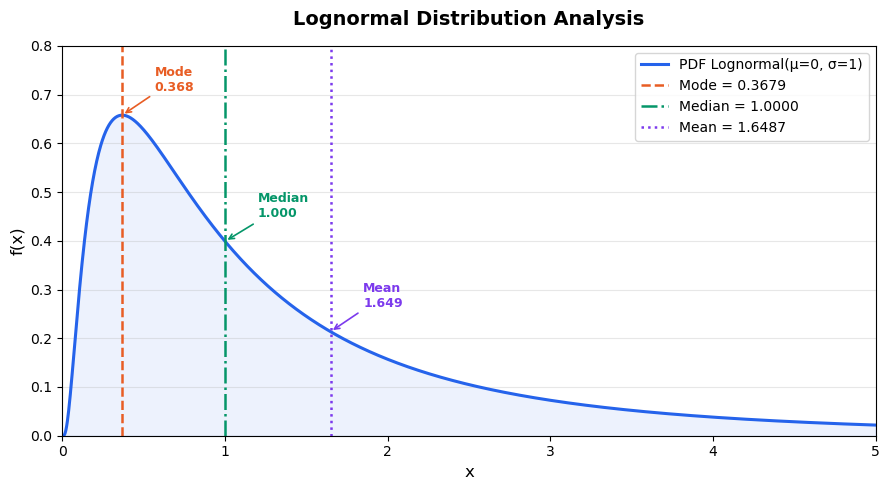

In [2]:
mu, sigma = 0, 1

x = np.linspace(0.001, 5, 2000)
pdf = lognorm.pdf(x, s=sigma, scale=np.exp(mu))

#statistics
mode   = np.exp(mu - sigma**2) 
median = np.exp(mu)
mean   = np.exp(mu + sigma**2 / 2)

#plot
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(x, pdf, color='#2563EB', linewidth=2.2, label=f'PDF Lognormal(μ={mu}, σ={sigma})')
ax.fill_between(x, pdf, alpha=0.08, color='#2563EB')

summary_stats = {
    'Mode':   (mode,   '#E85D24', '--'),
    'Median': (median, '#059669', '-.'),
    'Mean':   (mean,   '#7C3AED', ':'),
}

for label, (val, color, ls) in summary_stats.items():
    ax.axvline(val, color=color, linewidth=1.8, linestyle=ls, label=f'{label} = {val:.4f}')
    ax.annotate(f'{label}\n{val:.3f}', 
                xy=(val, lognorm.pdf(val, s=sigma, scale=np.exp(mu))),
                xytext=(val + 0.2, lognorm.pdf(val, s=sigma, scale=np.exp(mu)) + 0.05),
                fontsize=9, color=color, fontweight='bold',
                arrowprops=dict(arrowstyle='->', color=color, lw=1.2))

ax.set_xlim(0, 5)
ax.set_ylim(0, 0.8)
ax.set_xlabel('x', fontsize=12)
ax.set_ylabel('f(x)', fontsize=12)
ax.set_title('Lognormal Distribution Analysis', fontsize=14, fontweight='bold', pad=15)
ax.legend(loc='upper right')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()

#plt.savefig('lognormal_distribution.png', dpi=150)
plt.show()

## Problem 2: Elicitability


### Definition

A statistical functional $T(F)$ is called **elicitable** if there exists a scoring function $S : \mathbb{R} \times \mathbb{R} \to \mathbb{R}$ that is **strictly consistent** for $T$, meaning:

$$T(F) = \underset{x \in \mathbb{R}}{\arg\min}\ \mathbb{E}_F[S(x, Y)]$$

for all distributions $F$ in the relevant class, with the minimiser being unique.

### Proposition

For any $\tau \in (0, 1)$, the $\tau$-quantile functional

$$Q_\tau(F) = \inf\{x \in \mathbb{R} : F(x) \ge \tau\}$$

is elicitable. A strictly consistent scoring function is the **pinball loss** (also known as the check function):

$$S(x, y) = (y - x)\bigl(\tau - \mathbf{1}_{\{y < x\}}\bigr) = \rho_\tau(y - x)$$

where

$$\rho_\tau(u) = u\bigl(\tau - \mathbf{1}_{\{u < 0\}}\bigr) = \begin{cases} \tau\, u, & u \ge 0 \\[4pt] (\tau - 1)\,u, & u < 0 \end{cases}$$

### Proof

Let $Y \sim F$ and define the expected score as a function of the point forecast $x$:

$$\bar{S}(x) = \mathbb{E}_F[S(x, Y)] = \int_{-\infty}^{\infty} \rho_\tau(y - x)\, \mathrm{d}F(y)$$

**Step 1: Differentiate $\bar{S}(x)$ with respect to $x$.**

By the Leibniz integral rule, and noting that $\rho_\tau$ is absolutely continuous:

$$\frac{\mathrm{d}}{\mathrm{d}x}\bar{S}(x) = \int_{-\infty}^{\infty} \frac{\partial}{\partial x}\rho_\tau(y - x)\, \mathrm{d}F(y)$$

Computing the partial derivative directly by applying the chain rule:

$$\frac{\partial}{\partial x}\rho_\tau(y - x) = \bigl(\tau - \mathbf{1}_{\{y - x < 0\}}\bigr) \cdot (-1) = \mathbf{1}_{\{y < x\}} - \tau$$  

Therefore, by taking the expectation:

$$\frac{\mathrm{d}}{\mathrm{d}x}\bar{S}(x) = \mathbb{E}_F[\mathbf{1}_{\{Y < x\}} - \tau] = \mathbb{P}(Y < x) - \tau = F(x) - \tau$$

**Step 2: Identify the minimiser.**

Setting the first derivative to zero:

$$\frac{\mathrm{d}}{\mathrm{d}x}\bar{S}(x) = 0 \iff F(x) - \tau = 0 \iff F(x) = \tau \iff x = Q_\tau(F)$$

**Step 3: Verify that $Q_\tau(F)$ is a strict global minimum.**

Taking the second derivative:

$$\frac{\mathrm{d}^2}{\mathrm{d}x^2}\bar{S}(x) = f(x) \ge 0$$

where $f$ is the density of $F$. For any continuous distribution satisfying $f(Q_\tau) > 0$, this is strictly positive at the minimiser. Moreover, the monotonicity argument provides a cleaner global proof:

- For $x < Q_\tau(F)$: $F(x) < \tau$, so $\bar{S}'(x) < 0$ — $\bar{S}$ is strictly decreasing.
- For $x > Q_\tau(F)$: $F(x) > \tau$, so $\bar{S}'(x) > 0$ — $\bar{S}$ is strictly increasing.

Hence, for every $x \ne Q_\tau(F)$:

$$\mathbb{E}_F[S(x, Y)] > \mathbb{E}_F[S(Q_\tau(F), Y)]$$

#### Conclusion. The pinball loss $S(x, y) = \rho_\tau(y - x)$ is strictly consistent for the $\tau$-quantile functional $Q_\tau$. Therefore, the $\tau$-quantile is elicitable.

## Problem 3: The Markov Property

### Proposition

Let $X$, $Y$, $Z$ be random variables with a well-defined joint density. If $X$ is conditionally independent of $Y$ given $Z$, written $X \perp\!\!\!\perp Y \mid Z$, then:

$$f(x \mid z, y) = f(x \mid z) \qquad \text{for almost all } (x, y, z)$$

### Proof

**Step 1: Recall the definition of conditional independence.**

By definition, $X \perp\!\!\!\perp Y \mid Z$ if and only if the conditional joint density factorises as:

$$f(x, y \mid z) = f(x \mid z)\, f(y \mid z) \tag{1}$$

for almost all $(x, y, z)$.

**Step 2: Apply the chain rule for conditional densities.**

By the standard factorisation of conditional densities:

$$f(x, y \mid z) = f(x \mid z, y)\, f(y \mid z) \tag{2}$$

**Step 3: Combine equations (1) and (2).**

Substituting (1) into (2):

$$f(x \mid z, y)\, f(y \mid z) = f(x \mid z)\, f(y \mid z)$$

**Step 4: Conclude.**

On the set $\{f(y \mid z) > 0\}$, which has full probability measure, dividing both sides by $f(y \mid z)$ yields:

$$\boxed{f(x \mid z, y) = f(x \mid z)}$$

This is precisely the stated identity. 

## Problem 4: Mathematical Proofs


### 1. Probability Integral Transform: $U \equiv F_X(X) \sim \text{Unif}([0,1])$

**Proof:**

Let $X$ be a continuous random variable with CDF $F_X$, and define $U = F_X(X)$.

We want to show $U \sim \text{Unif}([0,1])$, i.e., $P(U \leq u) = u$ for all $u \in [0,1]$.

Compute the CDF of $U$:

$$P(U \leq u) = P(F_X(X) \leq u)$$

Since $F_X$ is monotonically non-decreasing and continuous, we can apply its inverse $F_X^{-1}$ (quantile function):

$$P(F_X(X) \leq u) = P(X \leq F_X^{-1}(u))$$

By definition of the CDF:

$$P(X \leq F_X^{-1}(u)) = F_X(F_X^{-1}(u)) = u$$

Therefore:

$$P(U \leq u) = u, \quad \forall u \in [0,1]$$

This is exactly the CDF of $\text{Unif}([0,1])$. Also note that $F_X$ maps into $[0,1]$ by definition, so $U \in [0,1]$ almost surely.

$$\boxed{U = F_X(X) \sim \text{Unif}([0,1])} $$

---

### 2. Copula Density 

**Goal:** Derive the copula density formula:

$$c_X(u_1, \ldots, u_n) = \frac{f_X(q_{X_1}(u_1), \ldots, q_{X_n}(u_n))}{\prod_{i=1}^{n} f_{X_i}(q_{X_i}(u_i))}$$

**Setup:**

By **Sklar's Theorem**, the joint CDF $F_X(x_1, \ldots, x_n)$ can be written as:

$$F_X(x_1, \ldots, x_n) = C_X(F_{X_1}(x_1), \ldots, F_{X_n}(x_n))$$

where $C_X : [0,1]^n \to [0,1]$ is the copula, and $F_{X_i}$ are the marginal CDFs.

**Deriving the joint density:**

Differentiating both sides with respect to $x_1, \ldots, x_n$:

$$f_X(x_1, \ldots, x_n) = \frac{\partial^n}{\partial x_1 \cdots \partial x_n} C_X(F_{X_1}(x_1), \ldots, F_{X_n}(x_n))$$

Applying the chain rule:

$$f_X(x_1, \ldots, x_n) = c_X(F_{X_1}(x_1), \ldots, F_{X_n}(x_n)) \cdot \prod_{i=1}^{n} f_{X_i}(x_i)$$

where the **copula density** is defined as:

$$c_X(u_1, \ldots, u_n) = \frac{\partial^n}{\partial u_1 \cdots \partial u_n} C_X(u_1, \ldots, u_n)$$

**Solving for the copula density:**

Substituting $u_i = F_{X_i}(x_i)$, so $x_i = F_{X_i}^{-1}(u_i) = q_{X_i}(u_i)$:

$$f_X(q_{X_1}(u_1), \ldots, q_{X_n}(u_n)) = c_X(u_1, \ldots, u_n) \cdot \prod_{i=1}^{n} f_{X_i}(q_{X_i}(u_i))$$

Dividing both sides by $\prod_{i=1}^{n} f_{X_i}(q_{X_i}(u_i))$ (which is positive since all marginal densities are positive):

$$\boxed{c_X(u_1, \ldots, u_n) = \frac{f_X(q_{X_1}(u_1), \ldots, q_{X_n}(u_n))}{\prod_{i=1}^{n} f_{X_i}(q_{X_i}(u_i))}} $$

**Interpretation:** The copula density $c_X$ captures the dependence structure among the variables, normalized by the product of their marginal densities. When the variables are independent, $f_X$ factorizes and $c_X \equiv 1$.

## Problem 5: Python Simulations

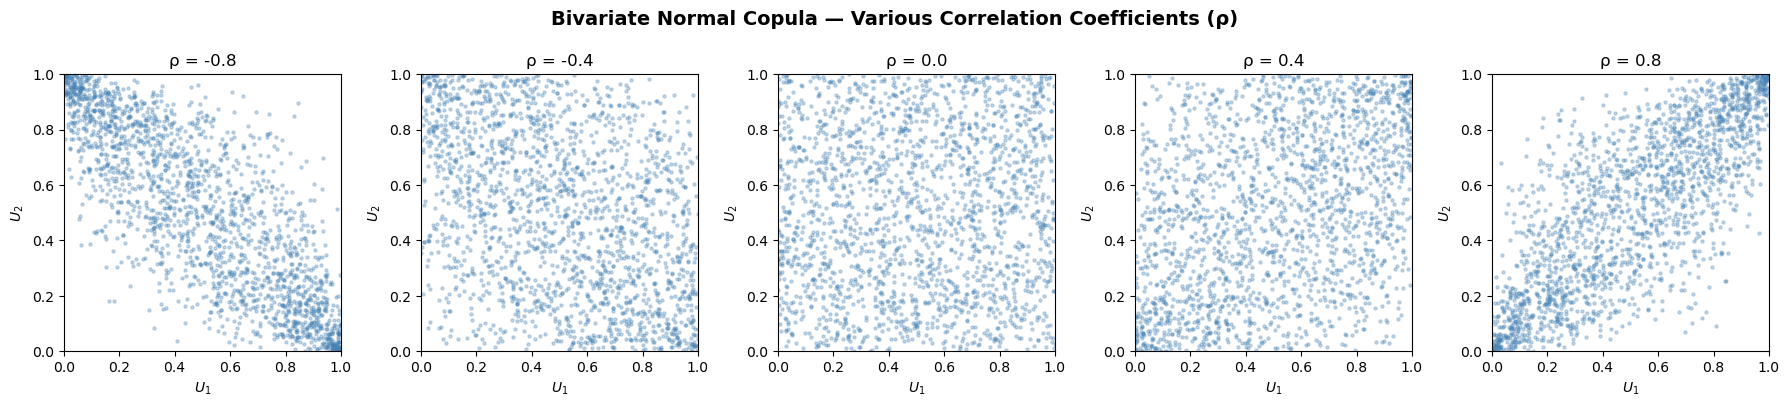

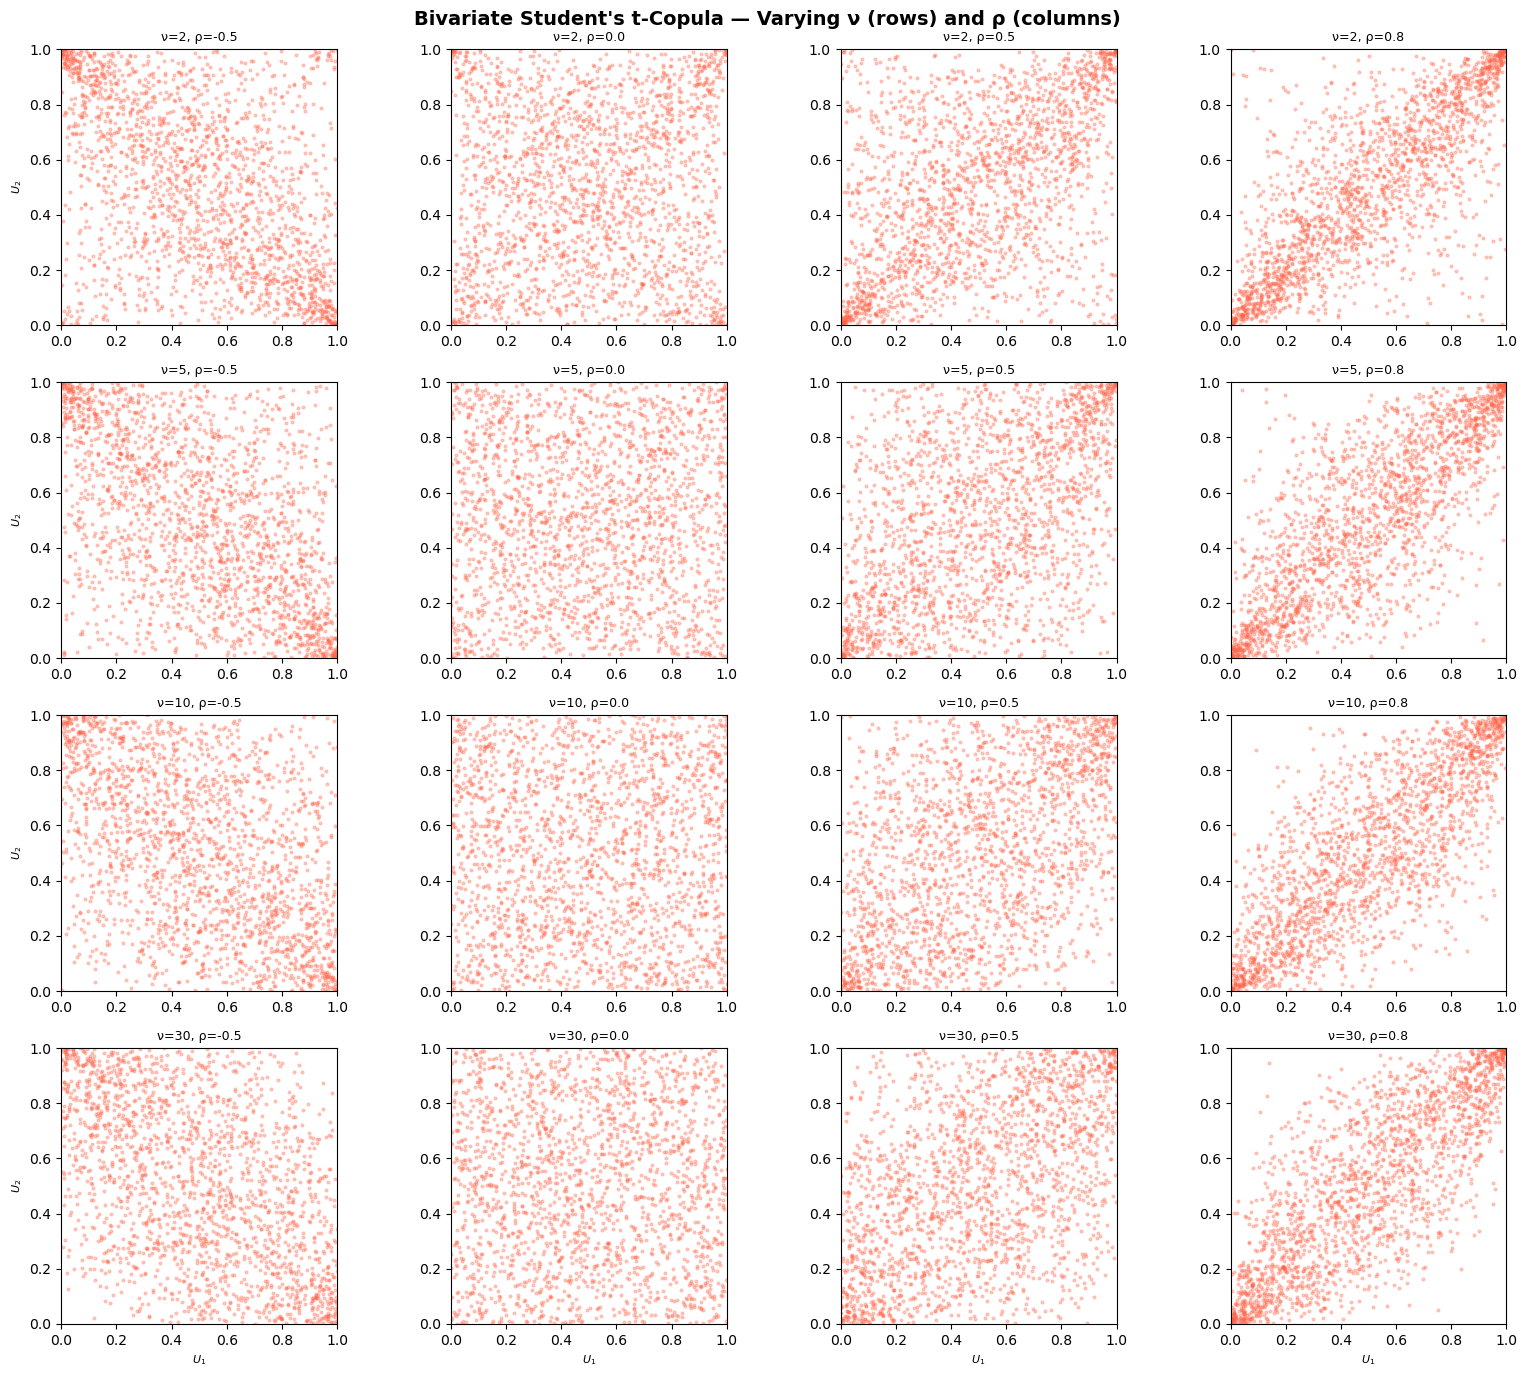

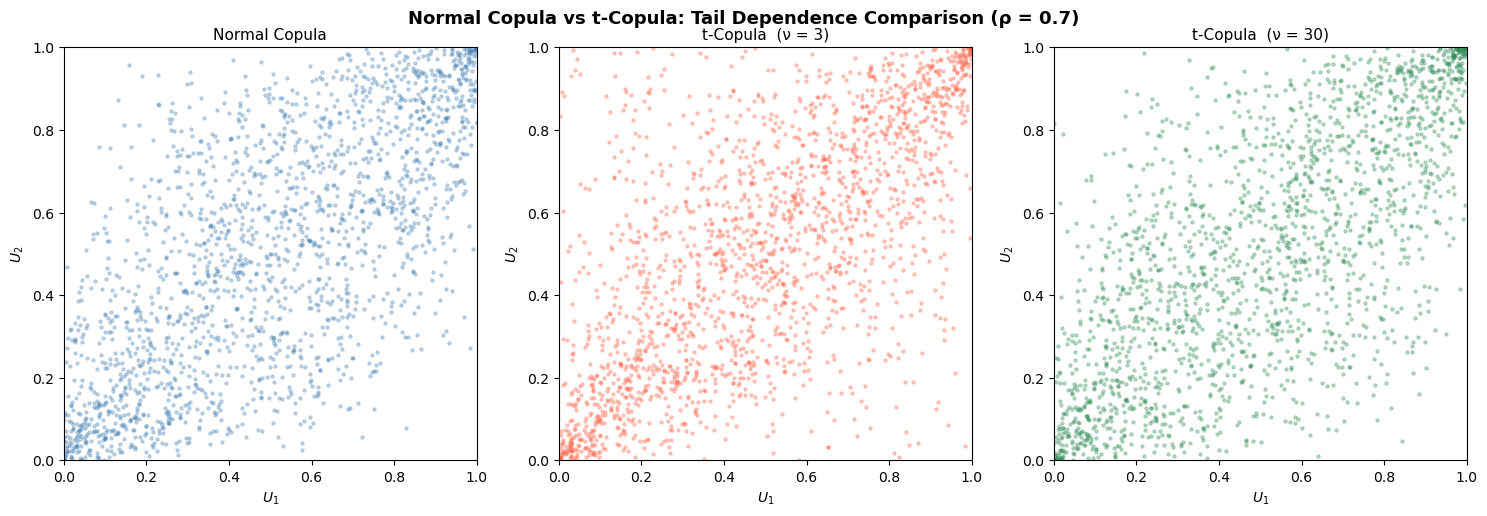

In [3]:
#Bivariate Normal Copula
def simulate_normal_copula(rho, n=2000):
    """Simulate from a bivariate Normal copula with correlation rho."""
    mean = [0, 0]
    cov = [[1, rho], [rho, 1]]
    Z = np.random.multivariate_normal(mean, cov, size=n)
    # Apply PIT to get uniform marginals
    U = norm.cdf(Z)
    return U

rhos = [-0.8, -0.4, 0.0, 0.4, 0.8]

fig, axes = plt.subplots(1, len(rhos), figsize=(18, 4))
fig.suptitle("Bivariate Normal Copula — Various Correlation Coefficients (ρ)",
             fontsize=14, fontweight='bold')

for ax, rho in zip(axes, rhos):
    U = simulate_normal_copula(rho)
    ax.scatter(U[:, 0], U[:, 1], alpha=0.3, s=5, color='steelblue')
    ax.set_title(f"ρ = {rho}", fontsize=12)
    ax.set_xlabel("$U_1$")
    ax.set_ylabel("$U_2$")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_aspect('equal')

plt.tight_layout()
#plt.savefig("normal_copula.png", dpi=150, bbox_inches='tight')
plt.show()



#Bivariate Student's t-Copula
def simulate_t_copula(rho, nu, n=2000):
    """Simulate from a bivariate Student's t-copula with df=nu, correlation=rho."""
    mean = [0, 0]
    cov = [[1, rho], [rho, 1]]
    # Step 1: Draw correlated normals
    Z = np.random.multivariate_normal(mean, cov, size=n)
    # Step 2: Draw chi-squared for the t-distribution
    chi2 = np.random.chisquare(df=nu, size=n)
    # Step 3: Construct bivariate t
    T = Z / np.sqrt(chi2[:, None] / nu)
    # Step 4: Apply PIT with t_nu CDF to get uniform marginals
    U = t.cdf(T, df=nu)
    return U

nus  = [2, 5, 10, 30]
rhos = [-0.5, 0.0, 0.5, 0.8]

fig, axes = plt.subplots(len(nus), len(rhos), figsize=(16, 14))
fig.suptitle("Bivariate Student's t-Copula — Varying ν (rows) and ρ (columns)",
             fontsize=14, fontweight='bold')

for i, nu in enumerate(nus):
    for j, rho in enumerate(rhos):
        ax = axes[i, j]
        U = simulate_t_copula(rho, nu)
        ax.scatter(U[:, 0], U[:, 1], alpha=0.3, s=4, color='tomato')
        ax.set_title(f"ν={nu}, ρ={rho}", fontsize=9)
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.set_aspect('equal')
        if j == 0:
            ax.set_ylabel("$U_2$", fontsize=8)
        if i == len(nus) - 1:
            ax.set_xlabel("$U_1$", fontsize=8)

plt.tight_layout()
#plt.savefig("t_copula.png", dpi=150, bbox_inches='tight')
plt.show()



#Side-by-side comparison

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Normal Copula vs t-Copula: Tail Dependence Comparison (ρ = 0.7)",
             fontsize=13, fontweight='bold')

rho = 0.7
configs = [
    ("Normal Copula",       simulate_normal_copula(rho),      'steelblue'),
    ("t-Copula  (ν = 3)",   simulate_t_copula(rho, nu=3),     'tomato'),
    ("t-Copula  (ν = 30)",  simulate_t_copula(rho, nu=30),    'seagreen'),
]

for ax, (title, U, color) in zip(axes, configs):
    ax.scatter(U[:, 0], U[:, 1], alpha=0.3, s=5, color=color)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("$U_1$")
    ax.set_ylabel("$U_2$")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_aspect('equal')

plt.tight_layout()
#plt.savefig("comparison_copula.png", dpi=150, bbox_inches='tight')
plt.show()


## Problem 6: Stock Return Analysis

In [4]:
mu = np.array([0.175, 0.133])
#in section 4.1
var1 = 0.424**2
var2 = 0.347**2
cov12 = -(0.285**2)

Sigma = np.array([[var1, cov12], 
                  [cov12, var2]])

print(f"Mean Vector:\n{mu}")
print(f"Covariance Matrix:\n{Sigma}")

# Calculate Z-score for realization x = [0.10, 0.10]
x = np.array([0.10, 0.10])
inv_Sigma = np.linalg.inv(Sigma)
diff = x - mu
# Mahalanobis distance formula
z_score_sq = diff.T @ inv_Sigma @ diff
z_score = np.sqrt(z_score_sq)
print(f"Absolute Multivariate Z-score: {z_score:.3f}")

Mean Vector:
[0.175 0.133]
Covariance Matrix:
[[ 0.179776 -0.081225]
 [-0.081225  0.120409]]
Absolute Multivariate Z-score: 0.291


Eigenvalues: [0.06361354 0.23657146]
Eigenvectors:
[[-0.57304217 -0.81952588]
 [-0.81952588  0.57304217]]


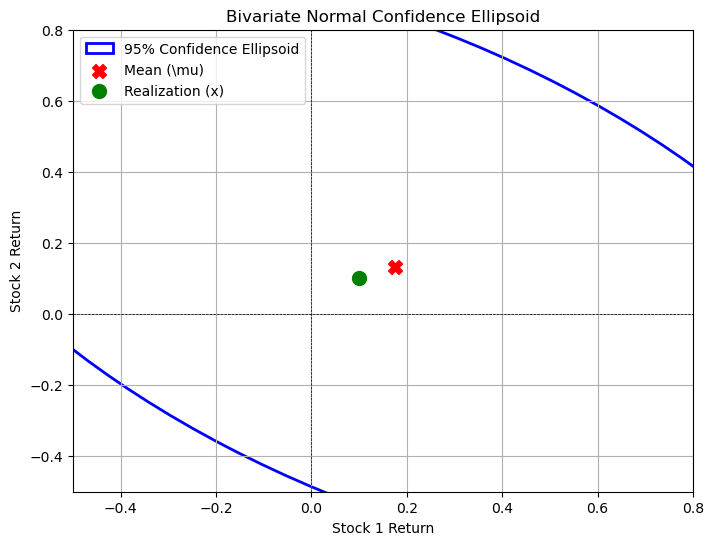

In [5]:
#Spectral Decomposition (PCA) & Visualization\
eigenvalues, eigenvectors = np.linalg.eigh(Sigma)
print(f"Eigenvalues: {eigenvalues}")
print(f"Eigenvectors:\n{eigenvectors}")

# Plotting the Confidence Ellipsoid
fig, ax = plt.subplots(figsize=(8, 6))

# 95% confidence interval using Chi-square distribution (df=2)
confidence_level = 0.95
chisq_val = chi2.ppf(confidence_level, df=2) 

# Calculate angle of the ellipse
angle = np.degrees(np.arctan2(eigenvectors[1, 0], eigenvectors[0, 0]))

# Calculate width and height of the ellipse
width, height = 2 * np.sqrt(chisq_val * eigenvalues)

ell = Ellipse(xy=mu, width=width, height=height, angle=angle, 
              edgecolor='blue', facecolor='none', lw=2, label='95% Confidence Ellipsoid')
ax.add_patch(ell)

# Plot Mean and the Realization x
ax.scatter(mu[0], mu[1], color='red', marker='X', s=100, label='Mean (\mu)')
ax.scatter(x[0], x[1], color='green', marker='o', s=100, label='Realization (x)')

ax.set_xlim(-0.5, 0.8)
ax.set_ylim(-0.5, 0.8)
ax.set_xlabel('Stock 1 Return')
ax.set_ylabel('Stock 2 Return')
ax.set_title('Bivariate Normal Confidence Ellipsoid')
ax.axhline(0, color='black', lw=0.5, ls='--')
ax.axvline(0, color='black', lw=0.5, ls='--')
ax.legend()
plt.grid(True)
plt.show()

In [6]:
#Portfolio Mean and Variance
w = np.array([0.2, 0.8])
port_mean = w.T @ mu
port_var = w.T @ Sigma @ w

print(f"Portfolio Mean: {port_mean:.4f} ({port_mean*100:.2f}%)")
print(f"Portfolio Variance: {port_var:.6f}")
print(f"Portfolio Standard Deviation (Volatility): {np.sqrt(port_var):.4f} ({np.sqrt(port_var)*100:.2f}%)")

Portfolio Mean: 0.1414 (14.14%)
Portfolio Variance: 0.058261
Portfolio Standard Deviation (Volatility): 0.2414 (24.14%)


## Problem 7: Linear Independence and Normal Coincidence

### 1. Affine Invariance: $X \perp\!\!\!\perp_{mc} Z \iff a_X + b_X X \perp\!\!\!\perp_{mc} a_Z + b_Z Z$

**Goal:** Prove that mean-covariance independence is invariant under affine transformations.

**Proof:**

By definition, $X \perp\!\!\!\perp_{mc} Z$ means that their covariance is zero, i.e., $\text{Cv}\{X, Z\} = \mathbf{0}$.

We compute the covariance of the affine transformations $a_X + b_X X$ and $a_Z + b_Z Z$. Using the affine equivariance of covariance (where constant additive terms vanish):

$$\text{Cv}\{a_X + b_X X, a_Z + b_Z Z\} = \text{Cv}\{b_X X, b_Z Z\} = b_X \text{Cv}\{X, Z\} b_Z^\top$$

Substituting the given condition $\text{Cv}\{X, Z\} = \mathbf{0}$:

$$\text{Cv}\{a_X + b_X X, a_Z + b_Z Z\} = b_X \cdot \mathbf{0} \cdot b_Z^\top = \mathbf{0}$$

Since the resulting covariance is zero, the transformed variables are also mean-covariance independent. (The reverse implication holds strictly provided $b_X$ and $b_Z$ are invertible matrices).

$$\boxed{a_X + b_X X \perp\!\!\!\perp_{mc} a_Z + b_Z Z}$$

---

### 2. Residual Properties

**Goal:** For the linear residual $\mathring{\varepsilon} \equiv X - \mathbb{E}\{X || Z\}$, prove that $\mathbb{E}\{\mathring{\varepsilon}\} = 0$ and $\text{Cv}\{\mathring{\varepsilon}, a + bZ\} = 0$.

**Setup:**

Recall the definition of the linear conditional expectation (linear projection):

$$\mathbb{E}\{X || Z\} \equiv \mu_X + \Sigma_{XZ}\Sigma_{ZZ}^{-1}(Z - \mu_Z)$$

where $\mu_X = \mathbb{E}\{X\}$, $\mu_Z = \mathbb{E}\{Z\}$, $\Sigma_{XZ} = \text{Cv}\{X, Z\}$, and $\Sigma_{ZZ} = \text{Cv}\{Z, Z\}$.

**Proof for $\mathbb{E}\{\mathring{\varepsilon}\} = 0$:**

Substitute the definition of the linear projection into the residual equation and apply the linearity of the expectation operator:

$$\mathbb{E}\{\mathring{\varepsilon}\} = \mathbb{E}\bigl\{X - \bigl[\mu_X + \Sigma_{XZ}\Sigma_{ZZ}^{-1}(Z - \mu_Z)\bigr]\bigr\}$$

$$\mathbb{E}\{\mathring{\varepsilon}\} = \mathbb{E}\{X\} - \mu_X - \Sigma_{XZ}\Sigma_{ZZ}^{-1}(\mathbb{E}\{Z\} - \mu_Z)$$

Since $\mathbb{E}\{X\} = \mu_X$ and $\mathbb{E}\{Z\} = \mu_Z$:

$$\mathbb{E}\{\mathring{\varepsilon}\} = \mu_X - \mu_X - \Sigma_{XZ}\Sigma_{ZZ}^{-1}(\mu_Z - \mu_Z) = \mathbf{0}$$

$$\boxed{\mathbb{E}\{\mathring{\varepsilon}\} = 0}$$

**Proof for $\text{Cv}\{\mathring{\varepsilon}, a + bZ\} = 0$:**

First, determine the covariance between the residual $\mathring{\varepsilon}$ and $Z$. Expanding the full residual form:

$$\text{Cv}\{\mathring{\varepsilon}, Z\} = \text{Cv}\bigl\{X - \bigl[\mu_X + \Sigma_{XZ}\Sigma_{ZZ}^{-1}(Z - \mu_Z)\bigr], Z\bigr\}$$

Since constant terms ($\mu_X$ and $\Sigma_{XZ}\Sigma_{ZZ}^{-1}\mu_Z$) vanish under the covariance operator, this simplifies to:

$$\text{Cv}\{\mathring{\varepsilon}, Z\} = \text{Cv}\bigl\{X - \Sigma_{XZ}\Sigma_{ZZ}^{-1}Z, Z\bigr\}$$

Applying the bilinearity of covariance:

$$\text{Cv}\{\mathring{\varepsilon}, Z\} = \text{Cv}\{X, Z\} - \Sigma_{XZ}\Sigma_{ZZ}^{-1}\text{Cv}\{Z, Z\}$$

Since $\text{Cv}\{Z, Z\} = \Sigma_{ZZ}$:

$$\text{Cv}\{\mathring{\varepsilon}, Z\} = \Sigma_{XZ} - \Sigma_{XZ}\Sigma_{ZZ}^{-1}\Sigma_{ZZ} = \Sigma_{XZ} - \Sigma_{XZ} = \mathbf{0}$$

Now, compute the covariance for any affine transformation $a + bZ$:

$$\text{Cv}\{\mathring{\varepsilon}, a + bZ\} = \text{Cv}\{\mathring{\varepsilon}, Z\} b^\top = \mathbf{0} \cdot b^\top = \mathbf{0}$$

$$\boxed{\text{Cv}\{\mathring{\varepsilon}, a + bZ\} = 0}$$

---

### 3. Total Covariance

**Goal:** Derive the decomposition $\text{Cv}\{X\} = \mathbb{E}\{\text{Cv}\{X || Z\}\} + \text{Cv}\{\mathbb{E}\{X || Z\}\}$.

**Setup:**

The linear conditional covariance is defined as the Schur complement:

$$\text{Cv}\{X || Z\} \equiv \Sigma_{XX} - \Sigma_{XZ}\Sigma_{ZZ}^{-1}\Sigma_{ZX}$$

**Proof:**

Decompose $X$ into its projected component and its residual component:

$$X = \mathbb{E}\{X || Z\} + \mathring{\varepsilon}$$

Take the covariance of both sides:

$$\text{Cv}\{X\} = \text{Cv}\{\mathbb{E}\{X || Z\} + \mathring{\varepsilon}\}$$

Expanding this using the bilinearity of covariance yields:

$$\text{Cv}\{X\} = \text{Cv}\{\mathbb{E}\{X || Z\}\} + \text{Cv}\{\mathring{\varepsilon}\} + \text{Cv}\{\mathbb{E}\{X || Z\}, \mathring{\varepsilon}\} + \text{Cv}\{\mathring{\varepsilon}, \mathbb{E}\{X || Z\}\}$$

Notice that $\mathbb{E}\{X || Z\} = \mu_X + \Sigma_{XZ}\Sigma_{ZZ}^{-1}(Z - \mu_Z)$ is an affine function of $Z$. By the Residual Properties proven above, the residual $\mathring{\varepsilon}$ is strictly orthogonal to any affine transformation of $Z$. Therefore, the cross-covariance terms equal zero, leaving:

$$\text{Cv}\{X\} = \text{Cv}\{\mathbb{E}\{X || Z\}\} + \text{Cv}\{\mathring{\varepsilon}\}$$

Next, we evaluate the covariance of the residual $\text{Cv}\{\mathring{\varepsilon}\}$. Let $A = \Sigma_{XZ}\Sigma_{ZZ}^{-1}$. Since constants vanish under covariance, $\text{Cv}\{\mathring{\varepsilon}\} = \text{Cv}\{X - AZ\}$. Using standard matrix expansion for the variance of a linear combination:

$$\text{Cv}\{\mathring{\varepsilon}\} = \Sigma_{XX} - A\Sigma_{ZX} - \Sigma_{XZ}A^\top + A\Sigma_{ZZ}A^\top$$

Substituting $A = \Sigma_{XZ}\Sigma_{ZZ}^{-1}$ back into the equation:

$$\text{Cv}\{\mathring{\varepsilon}\} = \Sigma_{XX} - (\Sigma_{XZ}\Sigma_{ZZ}^{-1})\Sigma_{ZX} - \Sigma_{XZ}(\Sigma_{ZZ}^{-1}\Sigma_{ZX}) + (\Sigma_{XZ}\Sigma_{ZZ}^{-1})\Sigma_{ZZ}(\Sigma_{ZZ}^{-1}\Sigma_{ZX})$$

$$\text{Cv}\{\mathring{\varepsilon}\} = \Sigma_{XX} - \Sigma_{XZ}\Sigma_{ZZ}^{-1}\Sigma_{ZX} - \Sigma_{XZ}\Sigma_{ZZ}^{-1}\Sigma_{ZX} + \Sigma_{XZ}\Sigma_{ZZ}^{-1}\Sigma_{ZX}$$

$$\text{Cv}\{\mathring{\varepsilon}\} = \Sigma_{XX} - \Sigma_{XZ}\Sigma_{ZZ}^{-1}\Sigma_{ZX}$$

This is exactly the definition of $\text{Cv}\{X || Z\}$. Because $\text{Cv}\{X || Z\}$ is a constant deterministic matrix, its expectation is simply itself:

$$\mathbb{E}\{\text{Cv}\{X || Z\}\} = \text{Cv}\{X || Z\} = \text{Cv}\{\mathring{\varepsilon}\}$$

Substituting $\mathbb{E}\{\text{Cv}\{X || Z\}\}$ back into our decomposed variance equation yields:

$$\boxed{\text{Cv}\{X\} = \mathbb{E}\{\text{Cv}\{X || Z\}\} + \text{Cv}\{\mathbb{E}\{X || Z\}\}}$$

---

### 4. Normal Coincidence

**Goal:** Under multivariate normality ($N$), show that linear operators coincide with conditional operators.

**Setup:**

Assume $(X, Z)$ follow a joint Multivariate Normal Distribution:

$$\begin{pmatrix} X \\ Z \end{pmatrix} \sim N\left( \begin{pmatrix} \mu_X \\ \mu_Z \end{pmatrix}, \begin{pmatrix} \Sigma_{XX} & \Sigma_{XZ} \\ \Sigma_{ZX} & \Sigma_{ZZ} \end{pmatrix} \right)$$

**Proof:**

Since the joint distribution is normal, the true conditional distribution $X | Z$ is mathematically guaranteed to be normal. We evaluate each operator:

**Expectation:** The linear form of the conditional expectation arises naturally from the density completion of the square in the Gaussian exponent. This yields the exact analytic mean $\mu_X + \Sigma_{XZ}\Sigma_{ZZ}^{-1}(Z - \mu_Z)$. This formula is identical to the definition of the linear projection.

$$\boxed{\mathbb{E}^N\{X || Z\} = \mathbb{E}^N\{X | Z\}}$$

**Covariance:** The true conditional covariance matrix of a multivariate normal distribution is derived as the Schur complement $\Sigma_{XX} - \Sigma_{XZ}\Sigma_{ZZ}^{-1}\Sigma_{ZX}$. This matrix is constant and does not depend on the specific realization of $Z$, making it identical to the definition of the linear conditional covariance.

$$\boxed{\text{Cv}^N\{X || Z\} = \text{Cv}^N\{X | Z\}}$$

**Independence:** In the mean-covariance framework, conditional independence $X \perp\!\!\!\perp_{mc} Y | Z$ implies that the partial covariance is zero ($\text{Cv}\{X, Y || Z\} = \mathbf{0}$). While zero covariance does not guarantee independence for general distributions, a Gaussian distribution is fully characterized by its mean and covariance. Thus, zero covariance forces the factorization of the joint conditional density into marginal densities, making it strictly equivalent to true probabilistic independence. 

$$\boxed{X \perp\!\!\!\perp_{mc} Y | Z \iff X \perp\!\!\!\perp Y | Z}$$

## Problem 8: Projection & Residuals

=== Numerical Validations ===
1. Orthogonality with Z:
   Cov(eta1, Z) = -0.00000 (Should be ~0)
   Cov(eta2, Z) = -0.00000 (Should be ~0)
2. Core Insight:
   Cov(eta1, eta2) = -0.20509 (Uncorrelated


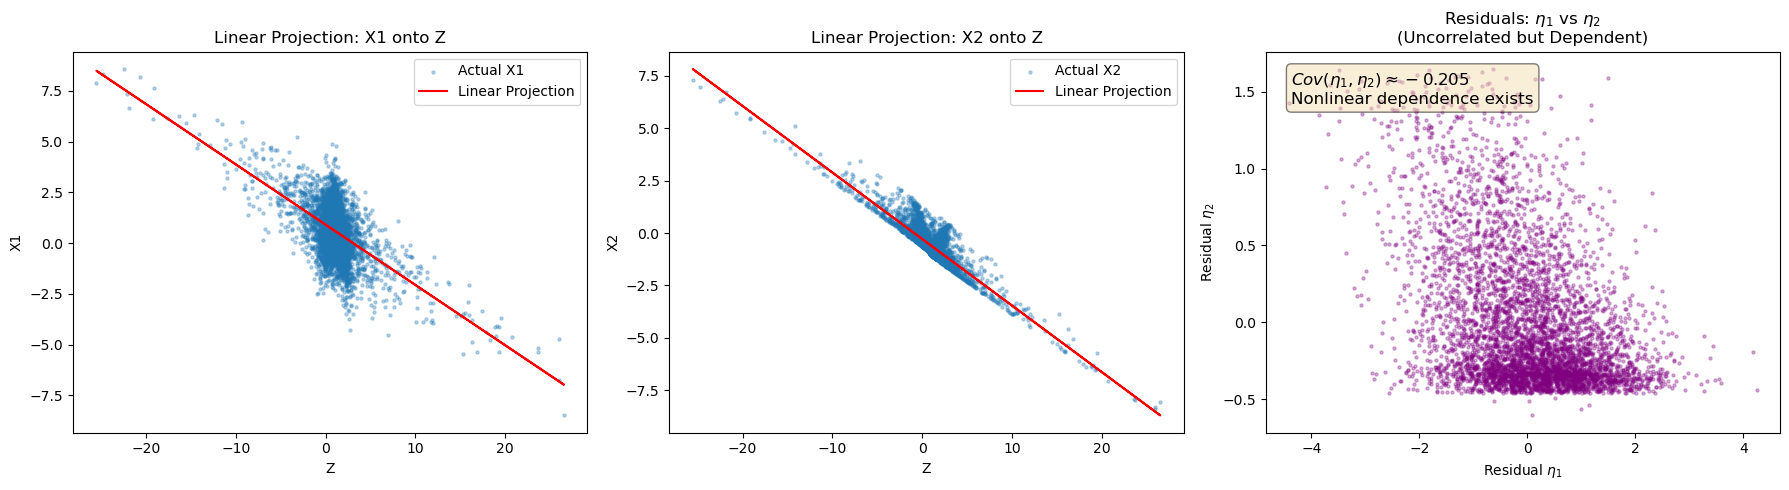

In [7]:
np.random.seed(42)
N = 5000
e1 = np.random.normal(0, 1, N)
e2 = np.random.normal(0, 1, N)
e3 = np.random.normal(0, 1, N)

c = (np.e - 1)**2 / (6 * np.e**2)

#variables
X1 = e1 + 0.2 * e2 + np.cos(e2) + 0.2 * (e3**3)
X2 = 0.2 * e2 + c * e3 - np.cos(e2) + 0.2 * (e3**3)
Z = 1 - (2/3) * (e2 + e3**3)


#Linear Projections : b = Cov(X, Z) / Var(Z)
var_Z = np.cov(Z, Z)[0, 0] 


b1 = np.cov(X1, Z)[0, 1] / var_Z
a1 = np.mean(X1) - b1 * np.mean(Z)
proj_X1 = a1 + b1 * Z
eta1 = X1 - proj_X1

b2 = np.cov(X2, Z)[0, 1] / var_Z
a2 = np.mean(X2) - b2 * np.mean(Z)
proj_X2 = a2 + b2 * Z
eta2 = X2 - proj_X2

#Numerical Validations
cov_eta1_Z = np.cov(eta1, Z)[0, 1]
cov_eta2_Z = np.cov(eta2, Z)[0, 1]
cov_eta1_eta2 = np.cov(eta1, eta2)[0, 1]

print("=== Numerical Validations ===")
print(f"1. Orthogonality with Z:")
print(f"   Cov(eta1, Z) = {cov_eta1_Z:.5f} (Should be ~0)")
print(f"   Cov(eta2, Z) = {cov_eta2_Z:.5f} (Should be ~0)")
print(f"2. Core Insight:")
print(f"   Cov(eta1, eta2) = {cov_eta1_eta2:.5f} (Uncorrelated")


# visulisation
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1 & 2
axes[0].scatter(Z, X1, alpha=0.3, s=5, label='Actual X1')
axes[0].plot(Z, proj_X1, color='red', label='Linear Projection')
axes[0].set_title('Linear Projection: X1 onto Z')
axes[0].set_xlabel('Z')
axes[0].set_ylabel('X1')
axes[0].legend()

axes[1].scatter(Z, X2, alpha=0.3, s=5, label='Actual X2')
axes[1].plot(Z, proj_X2, color='red', label='Linear Projection')
axes[1].set_title('Linear Projection: X2 onto Z')
axes[1].set_xlabel('Z')
axes[1].set_ylabel('X2')
axes[1].legend()

# Plot 3
axes[2].scatter(eta1, eta2, alpha=0.3, s=5, color='purple')
axes[2].set_title('Residuals: $\eta_1$ vs $\eta_2$\n(Uncorrelated but Dependent)')
axes[2].set_xlabel('Residual $\eta_1$')
axes[2].set_ylabel('Residual $\eta_2$')

textstr = f'$Cov(\eta_1, \eta_2) \\approx {cov_eta1_eta2:.3f}$\nNonlinear dependence exists'
props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
axes[2].text(0.05, 0.95, textstr, transform=axes[2].transAxes, fontsize=12,
        verticalalignment='top', bbox=props)

plt.tight_layout()
plt.show()

## Problem 9: Dataset Evaluation

In [8]:
df_f = pd.read_csv(r"data\furniture_series.csv", parse_dates=['Date'])
df_h = pd.read_csv(r"data\house_series.csv", parse_dates=['Date'])

#log
df = pd.merge(df_f[['Date', 'Close']], df_h[['Date', 'Close']], on='Date', suffixes=('_f', '_h'))
df.set_index('Date', inplace=True)
returns = np.log(df / df.shift(1)).dropna()
returns.columns = ['Furniture', 'House']

returns.head()

,Furniture,House
Date,,
2017-04-04 00:00:00-04:00,-0.001652,-0.000867
2017-04-05 00:00:00-04:00,-0.002180,-0.009929
2017-04-06 00:00:00-04:00,0.008058,-0.002170
2017-04-07 00:00:00-04:00,0.005550,-0.008364
2017-04-10 00:00:00-04:00,0.007116,0.000795


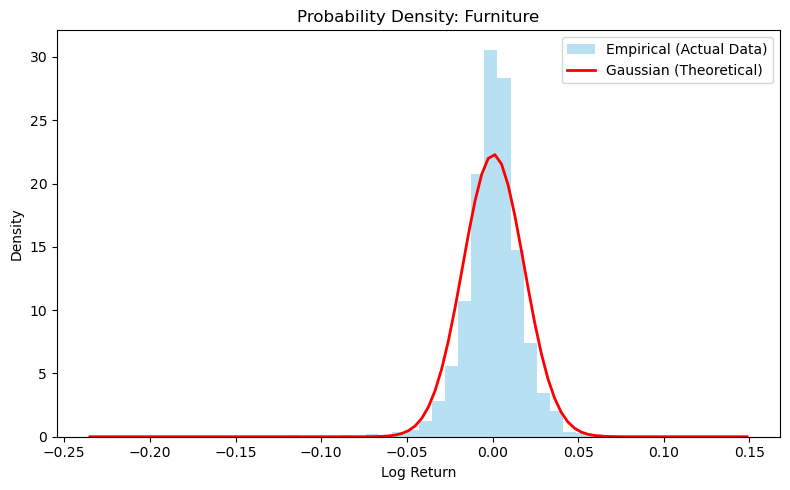


 Furniture:
 μ = 0.000529，σ = 0.017888


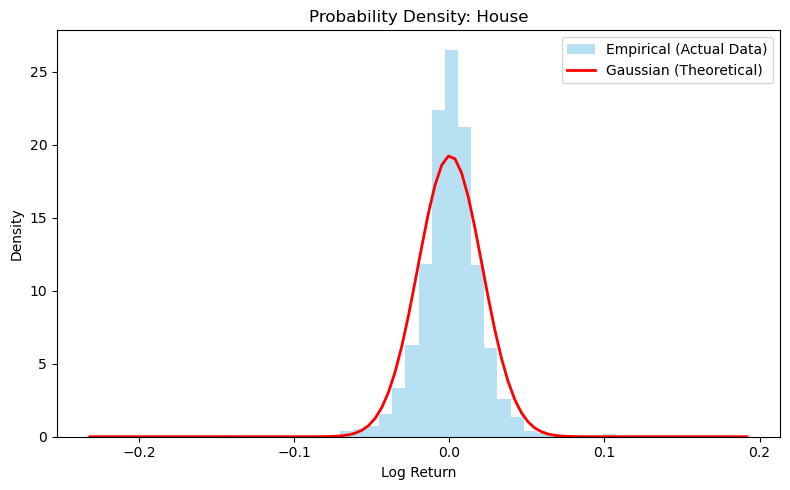


 House:
 μ = 0.000573，σ = 0.020705


In [9]:
#Probability density
def plot_density(data, name): 
    mu, std = data.mean(), data.std()
    fig, ax = plt.subplots(figsize=(8, 5)) 
    x = np.linspace(data.min(), data.max(), 100)

    ax.hist(data, bins=50, density=True, alpha=0.6, color='skyblue', label='Empirical (Actual Data)')

    ax.plot(x, norm.pdf(x, mu, std), 'r', lw=2, label='Gaussian (Theoretical)')
    
    ax.set_title(f'Probability Density: {name}')
    ax.set_xlabel('Log Return')
    ax.set_ylabel('Density')
    ax.legend()
    
    plt.tight_layout()
    #plt.savefig(f'density_{name.lower()}.png')
    plt.show() 

    print(f"\n {name}:")
    print(f" μ = {mu:.6f}，σ = {std:.6f}")
    


plot_density(returns['Furniture'], 'Furniture')
plot_density(returns['House'], 'House')

In [10]:
#Stylized Facts 

skew = returns.skew()
kurt = returns.kurtosis() + 3  ## pandas returns Fisher kurtosis, convert to Pearson by +3

facts = pd.DataFrame({
    'Skewness ': skew,
    'Pearson Kurtosis': kurt
}).round(4) 

print("Stylized Facts Summary:")
print(facts)
print("-" * 50)

#check
for col in returns.columns:
    s = skew[col]
    k = kurt[col]
    
    # Skewness Diagnosis
    skew_type = "Negative Skew" if s < 0 else "Positive Skew"
    skew_intensity = "Significant" if abs(s) > 0.5 else "Slight"
    
    # Kurtosis / Heavy Tail Diagnosis
    kurt_desc = "Significant Heavy Tails (Leptokurtic)" if k > 3 else "Near Normal Distribution"
    excess_k = k - 3
    
    print(f"【Analysis Conclusion for {col}】:")
    print(f" - Skewness: {s:.4f} ({skew_intensity} {skew_type}). High risk of extreme negative returns.")
    print(f" - Kurtosis: {k:.4f} ({kurt_desc}). Excess Kurtosis is {excess_k:.4f}, far exceeding the normal threshold.")
    print(f" - Summary: The return series exhibits typical 'Fat-Tail' and 'High-Peak' stylized facts of financial data.")
    print("-" * 50)

Stylized Facts Summary:
           Skewness   Pearson Kurtosis
Furniture    -1.0493           22.5861
House        -0.2532           19.2475
--------------------------------------------------
【Analysis Conclusion for Furniture】:
 - Skewness: -1.0493 (Significant Negative Skew). High risk of extreme negative returns.
 - Kurtosis: 22.5861 (Significant Heavy Tails (Leptokurtic)). Excess Kurtosis is 19.5861, far exceeding the normal threshold.
 - Summary: The return series exhibits typical 'Fat-Tail' and 'High-Peak' stylized facts of financial data.
--------------------------------------------------
【Analysis Conclusion for House】:
 - Skewness: -0.2532 (Slight Negative Skew). High risk of extreme negative returns.
 - Kurtosis: 19.2475 (Significant Heavy Tails (Leptokurtic)). Excess Kurtosis is 16.2475, far exceeding the normal threshold.
 - Summary: The return series exhibits typical 'Fat-Tail' and 'High-Peak' stylized facts of financial data.
----------------------------------------------

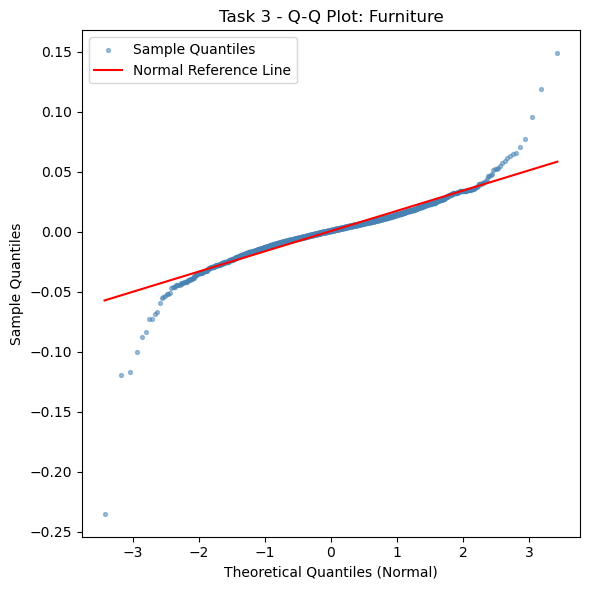


[Task 3 - Detailed Non-Normality and Tail Analysis for Furniture]
R² (Overall Fit): 0.8899
Jarque-Bera Test: Statistic = 36012.7652, p-value = 0.0000e+00
 -> Interpretation: Reject the null hypothesis of normal distribution (p < 0.05).
Skewness = -1.0486, Pearson Kurtosis = 22.5396
 -> Large Kurtosis suggests significant HEAVY TAILS (fat tails).
--------------------------------------------------
Specific Extreme Tail Deviation Quantification:
 Theoretical 1st Percentile (Normal): -2.3263
 Sample 1st Percentile:               -0.0447
 -> Lower tail deviation indicates THIN tails.
 Theoretical 99th Percentile (Normal): 2.3263
 Sample 99th Percentile:              0.0411
 -> Upper tail deviation indicates THIN tails.
--------------------------------------------------


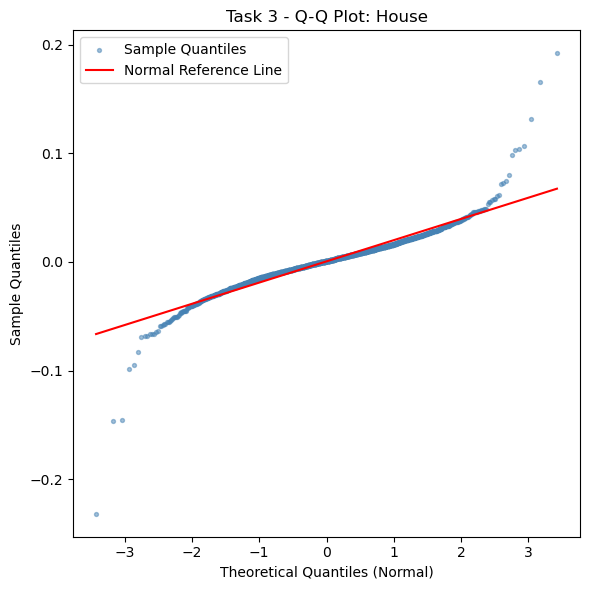


[Task 3 - Detailed Non-Normality and Tail Analysis for House]
R² (Overall Fit): 0.8884
Jarque-Bera Test: Statistic = 24522.3497, p-value = 0.0000e+00
 -> Interpretation: Reject the null hypothesis of normal distribution (p < 0.05).
Skewness = -0.2530, Pearson Kurtosis = 19.2086
 -> Large Kurtosis suggests significant HEAVY TAILS (fat tails).
--------------------------------------------------
Specific Extreme Tail Deviation Quantification:
 Theoretical 1st Percentile (Normal): -2.3263
 Sample 1st Percentile:               -0.0542
 -> Lower tail deviation indicates THIN tails.
 Theoretical 99th Percentile (Normal): 2.3263
 Sample 99th Percentile:              0.0479
 -> Upper tail deviation indicates THIN tails.
--------------------------------------------------


In [11]:
#Q-Q plot
def plot_qq(data, name):
 
    fig, ax = plt.subplots(figsize=(6, 6))

    #(osm, osr)
    (osm, osr), (slope, intercept, r) = probplot(data, dist='norm')

    ax.scatter(osm, osr, s=8, alpha=0.5, color='steelblue', label='Sample Quantiles')
    #normal line
    line_x = np.array([osm.min(), osm.max()])
    ax.plot(line_x, slope * line_x + intercept, 'r-', lw=1.5, label='Normal Reference Line')

    ax.set_title(f'Task 3 - Q-Q Plot: {name}')
    ax.set_xlabel('Theoretical Quantiles (Normal)')
    ax.set_ylabel('Sample Quantiles')
    ax.legend()
    plt.tight_layout()
    #plt.savefig(f'task3_qqplot_{name.lower()}.png', dpi=150)
    plt.show()

    
    # Extended Detailed Tail Analysis Section
    print(f"\n[Task 3 - Detailed Non-Normality and Tail Analysis for {name}]")
    print(f"R² (Overall Fit): {r**2:.4f}")

    # 1. Jarque-Bera Test (Formal Statistical Test for Normality)
    jb_stats, jb_p = jarque_bera(data)
    print(f"Jarque-Bera Test: Statistic = {jb_stats:.4f}, p-value = {jb_p:.4e}")
    if jb_p < 0.05:
        print(" -> Interpretation: Reject the null hypothesis of normal distribution (p < 0.05).")
    else:
        print(" -> Interpretation: Fail to reject the null hypothesis of normal distribution (p >= 0.05).")

    # 2. Skewness and Pearson Kurtosis
    skew = stats.skew(data)
    # fisher=False gives Pearson kurtosis (Normal=3)
    # fisher=True gives Excess kurtosis (Normal=0)
    kurt = stats.kurtosis(data, fisher=False) 
    print(f"Skewness = {skew:.4f}, Pearson Kurtosis = {kurt:.4f}")
    if kurt > 3:
        print(" -> Large Kurtosis suggests significant HEAVY TAILS (fat tails).")
    elif kurt < 3:
        print(" -> Low Kurtosis suggests THINNER TAILS than a normal distribution.")

    # 3. Targeted Extreme Quantile Comparison (visualized deviation quantificaton)
    theoretical_1st = stats.norm.ppf(0.01)
    sample_1st = np.percentile(data, 1)
    theoretical_99th = stats.norm.ppf(0.99)
    sample_99th = np.percentile(data, 99)

    print("-" * 50)
    print("Specific Extreme Tail Deviation Quantification:")
    print(f" Theoretical 1st Percentile (Normal): {theoretical_1st:.4f}")
    print(f" Sample 1st Percentile:               {sample_1st:.4f}")
    # Compare absolute values for lower tail
    lower_tail_dev = "HEAVY" if abs(sample_1st) > abs(theoretical_1st) else "THIN"
    print(f" -> Lower tail deviation indicates {lower_tail_dev} tails.")

    print(f" Theoretical 99th Percentile (Normal): {theoretical_99th:.4f}")
    print(f" Sample 99th Percentile:              {sample_99th:.4f}")
    upper_tail_dev = "HEAVY" if sample_99th > theoretical_99th else "THIN"
    print(f" -> Upper tail deviation indicates {upper_tail_dev} tails.")
    print("-" * 50)


plot_qq(returns['Furniture'].dropna(), 'Furniture')
plot_qq(returns['House'].dropna(), 'House')



Spearman's rho: 0.5305
Kendall's tau: 0.3792


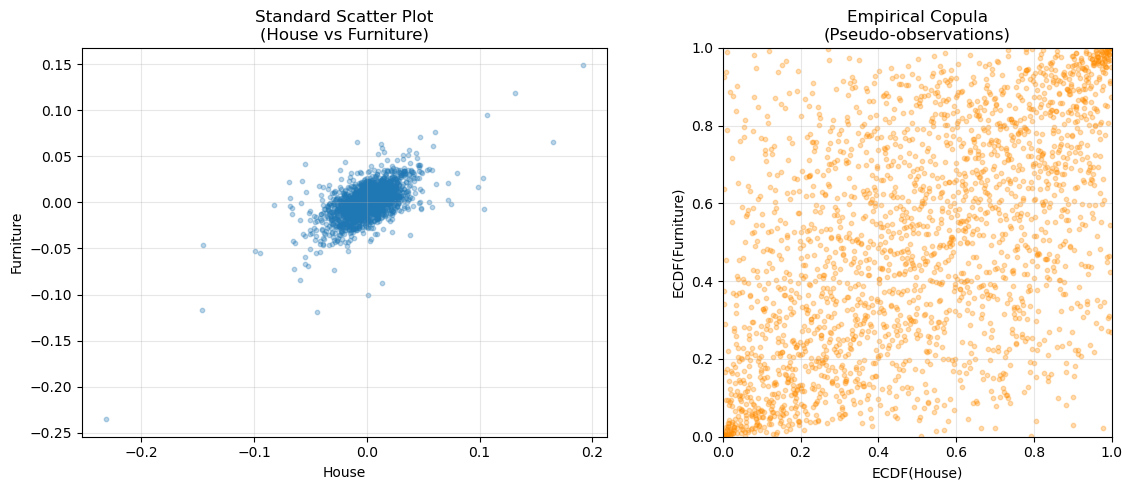

In [12]:
#Dependence Structure
def plot_dependence_structure(df, col1, col2):

    x = df[col1]
    y = df[col2]
    
    #rank-based correlation coefficients
    spearman_corr, _ = spearmanr(x, y)
    kendall_corr, _ = kendalltau(x, y)
    
    print(f"Spearman's rho: {spearman_corr:.4f}")
    print(f"Kendall's tau: {kendall_corr:.4f}")

    
    # Transform marginals to uniform [0, 1] using Empirical CDF (Pseudo-observations)
    # This forms the basis of the empirical copula
    u1 = rankdata(x) / (len(x) + 1)
    u2 = rankdata(y) / (len(y) + 1)


    
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    #Standard Scatter Plot
    axes[0].scatter(x, y, alpha=0.3, s=10)
    axes[0].set_title(f'Standard Scatter Plot\n({col1} vs {col2})')
    axes[0].set_xlabel(col1)
    axes[0].set_ylabel(col2)
    axes[0].grid(True, alpha=0.3)
    
    #Empirical Copula Scatter Plot
    axes[1].scatter(u1, u2, alpha=0.3, s=10, color='darkorange')
    axes[1].set_title('Empirical Copula\n(Pseudo-observations)')
    axes[1].set_xlabel(f'ECDF({col1})')
    axes[1].set_ylabel(f'ECDF({col2})')
    axes[1].set_xlim(0, 1)
    axes[1].set_ylim(0, 1)
    axes[1].set_aspect('equal') # Ensure square aspect for copula
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
plot_dependence_structure(returns, 'House', 'Furniture')


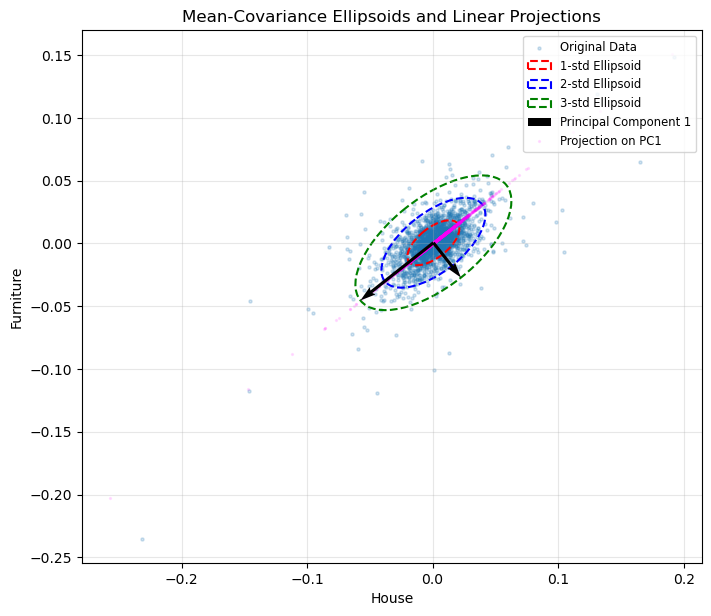

In [13]:
# Advanced Visualization
def advanced_visualization(df, col1, col2):
    x = df[col1].values
    y = df[col2].values

    #basics
    mean = np.mean([x, y], axis=1)
    cov = np.cov(x, y)
    
    eigenvalues, eigenvectors = np.linalg.eigh(cov)
    
    order = eigenvalues.argsort()[::-1]
    eigenvalues = eigenvalues[order]
    eigenvectors = eigenvectors[:, order]

    
    # rotation angle
    angle = np.degrees(np.arctan2(*eigenvectors[:, 0][::-1]))
    
    fig, ax = plt.subplots(figsize=(8, 8))
    

    ax.scatter(x, y, alpha=0.2, s=5, label='Original Data')
    
    #Mean-Covariance Ellipsoids
    colors = ['red', 'blue', 'green']
    for n_std, color in zip([1, 2, 3], colors):
        # Ellipse dimensions are scaled by standard deviations and sqrt of eigenvalues
        width = 2 * n_std * np.sqrt(eigenvalues[0])
        height = 2 * n_std * np.sqrt(eigenvalues[1])
        
        ell = Ellipse(xy=mean, width=width, height=height, angle=angle,
                      edgecolor=color, facecolor='none', linestyle='--',
                      linewidth=1.5, label=f'{n_std}-std Ellipsoid')
        ax.add_patch(ell)
    
    #linear projections (Principal Components / Eigenvectors)
    for i in range(2):
        # Scale eigenvector by 3 standard deviations for visual representation
        vec = eigenvectors[:, i] * np.sqrt(eigenvalues[i]) * 3
        ax.quiver(mean[0], mean[1], vec[0], vec[1], angles='xy', scale_units='xy', 
                  scale=1, color='black', width=0.005, zorder=5,
                  label=f'Principal Component {i+1}' if i==0 else None)
    
    # Calculate and plot orthogonal projection onto the first principal component
    # 1. Center the data
    centered_data = np.column_stack((x - mean[0], y - mean[1]))
    pc1_vector = eigenvectors[:, 0]
    # 2. Project onto PC1
    projection_scalars = np.dot(centered_data, pc1_vector)
    # 3. Translate back to original space
    projected_points = mean + np.outer(projection_scalars, pc1_vector)
    
    ax.scatter(projected_points[:, 0], projected_points[:, 1], color='magenta', 
               alpha=0.1, s=2, zorder=1, label='Projection on PC1')
    
    # Enforce equal aspect ratio to prevent geometric distortion
    ax.set_aspect('equal')
    
    ax.set_title('Mean-Covariance Ellipsoids and Linear Projections')
    ax.set_xlabel(col1)
    ax.set_ylabel(col2)
    ax.legend(loc='upper right', fontsize='small')
    plt.grid(True, alpha=0.3)
    plt.show()
advanced_visualization(returns, 'House', 'Furniture')
